# 04. Model Evaluation

This notebook provides a comprehensive evaluation of the four 
trained models from `03_modeling.ipynb`, with a focus on 
translating model performance into business insights.

**Sections covered:**
1. Load Models & Data
2. Confusion Matrix Analysis
3. ROC Curve & Precision-Recall Curve Comparison
4. Feature Importance Deep Dive
5. Final Model Selection
6. Business Recommendations

## 1. Load Models & Data

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# File and metadata management
from pathlib import Path

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Machine learning
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)

# Model persistence
import joblib

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Suppress warnings for cleaner output
import warnings
def warn(*args, **kwargs):
    pass
warnings.warn = warn
warnings.filterwarnings("ignore")

In [4]:
# Load processed data
data_path  = Path("../data/processed")
model_path = Path("../outputs/models")

X_test = pd.read_csv(data_path / "X_test.csv")
y_test = pd.read_csv(data_path / "y_test.csv").squeeze()

# Load models
lr     = joblib.load(model_path / "logistic_regression.pkl")
rf     = joblib.load(model_path / "random_forest.pkl")
xgb    = joblib.load(model_path / "xgboost.pkl")
xgb_sm = joblib.load(model_path / "xgboost_smote.pkl")

print("Models and data loaded successfully.")
print(f"Test set: {X_test.shape[0]:,} records")

Models and data loaded successfully.
Test set: 29,878 records


In [5]:
# Generate predictions for all models
models = {
    'Logistic Regression': lr,
    'Random Forest':       rf,
    'XGBoost':             xgb,
    'XGBoost + SMOTE':     xgb_sm,
}

preds   = {name: model.predict(X_test) 
           for name, model in models.items()}
probas  = {name: model.predict_proba(X_test)[:, 1] 
           for name, model in models.items()}

print("Predictions generated for all models.")

Predictions generated for all models.


## 2. Confusion Matrix Analysis

A confusion matrix breaks down model predictions into four categories:

| | Predicted: No Default | Predicted: Default |
|---|---|---|
| **Actual: No Default** | True Negative (TN) ✅ | False Positive (FP) ⚠️ |
| **Actual: Default** | False Negative (FN) ❌ | True Positive (TP) ✅ |

**In a credit risk context, the cost of each error type differs:**

- **False Negative (FN)** — The model predicted "no default" but the 
  borrower actually defaulted. The lender approves a loan that goes bad. 
  This is the **most costly error** — it results in direct financial loss.

- **False Positive (FP)** — The model predicted "default" but the 
  borrower would have repaid. The lender rejects a good borrower. 
  This results in lost revenue opportunity, but no direct loss.

Given this asymmetry, **minimising False Negatives (maximising Recall)** 
is the primary objective in credit risk modelling.

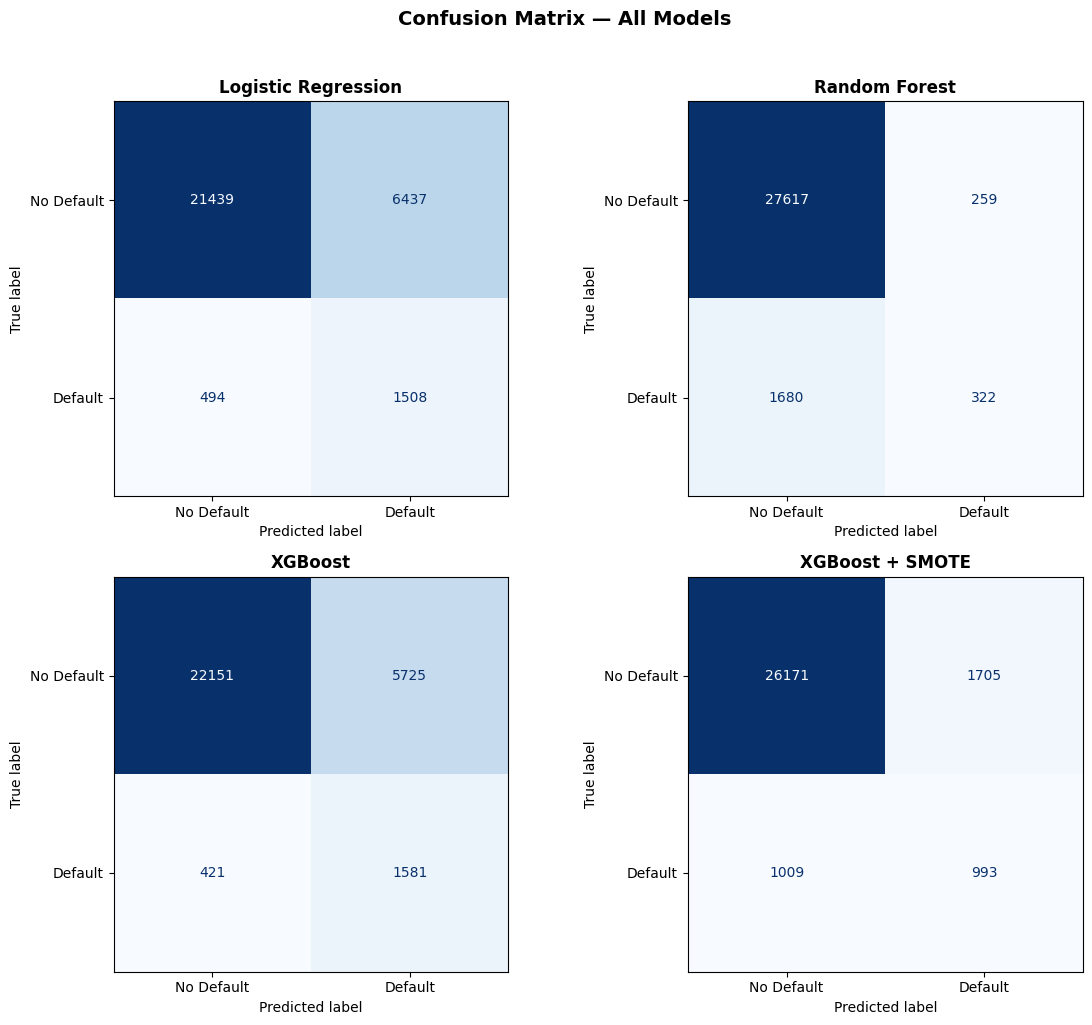

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, pred) in enumerate(preds.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Default', 'Default']
    )
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix — All Models', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Confusion Matrix Observations:**

- **Logistic Regression & XGBoost** prioritise catching defaulters 
  (high TP, high FP) — aggressive in flagging default risk, 
  resulting in more false alarms but fewer missed defaulters.

- **Random Forest** is the most conservative — high TN and precision, 
  but misses the majority of actual defaulters (high FN Rate). 
  This behaviour is dangerous in credit risk: most defaulters 
  would be approved for loans.

- **XGBoost + SMOTE** offers a middle ground — fewer missed 
  defaulters than Random Forest, fewer false alarms than 
  Logistic Regression and XGBoost.

The **FN Rate** is the critical metric here. A high FN Rate means 
the model is systematically approving loans that will default.

## 3. ROC Curve & Precision-Recall Curve

Two complementary curves are used to evaluate model performance:

**ROC Curve (AUC-ROC)**
Measures overall discrimination ability across all thresholds. 
Useful for general model comparison, but can be overly optimistic 
when classes are heavily imbalanced.

**Precision-Recall Curve (AUC-PR)**
Focuses exclusively on the minority class (defaulters). 
Unlike ROC, it is not influenced by the large number of 
true negatives, making it a more honest evaluation metric 
for imbalanced datasets like this one (6.7% positive class).

The **baseline for PR Curve** is the positive class ratio (0.067) — 
a random classifier would achieve AUC-PR ≈ 0.067. 
Any model significantly above this line is adding value.

Both curves are presented together for a complete picture.

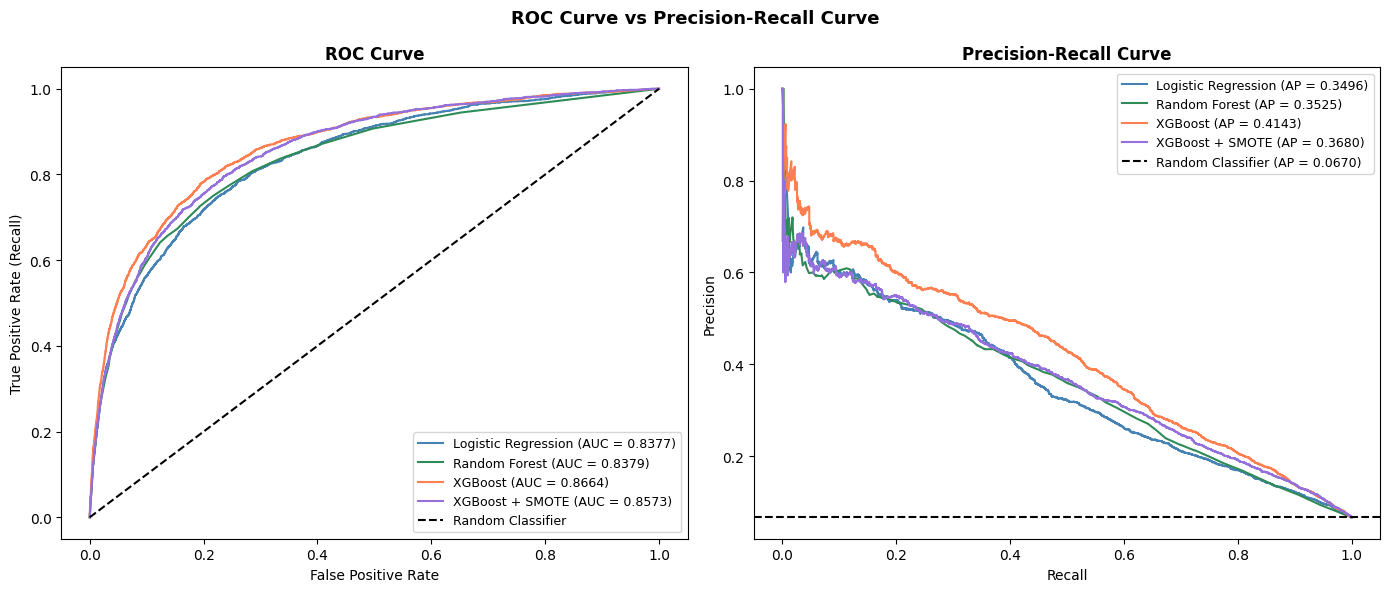

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['steelblue', 'seagreen', 'coral', 'mediumpurple']

# ── ROC Curve ────────────────────────────────────────────────
for (name, proba), color in zip(probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", 
                 color=color)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)

# ── PR Curve ─────────────────────────────────────────────────
baseline = y_test.mean()

for (name, proba), color in zip(probas.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, 
                 label=f"{name} (AP = {ap:.4f})", color=color)

axes[1].axhline(y=baseline, color='k', linestyle='--', 
                label=f'Random Classifier (AP = {baseline:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('ROC Curve vs Precision-Recall Curve', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Summary table — ROC AUC and PR AUC side by side
summary = []
for name in models:
    pred  = preds[name]
    proba = probas[name]
    summary.append({
        'Model':    name,
        'AUC-ROC':  round(roc_auc_score(y_test, proba), 4),
        'AUC-PR':   round(average_precision_score(y_test, proba), 4),
        'Precision':round(precision_score(y_test, pred), 4),
        'Recall':   round(recall_score(y_test, pred), 4),
        'F1-Score': round(f1_score(y_test, pred), 4),
    })

summary_df = pd.DataFrame(summary).set_index('Model')
print(summary_df)

                     AUC-ROC  AUC-PR  Precision  Recall  F1-Score
Model                                                            
Logistic Regression   0.8377  0.3496     0.1898  0.7532    0.3032
Random Forest         0.8379  0.3525     0.5542  0.1608    0.2493
XGBoost               0.8664  0.4143     0.2164  0.7897    0.3397
XGBoost + SMOTE       0.8573  0.3680     0.3681  0.4960    0.4226


**ROC vs PR Curve Observations:**

The PR Curve reveals a more nuanced picture than ROC alone:

- All models show AUC-PR significantly above the random baseline 
  (0.067), confirming genuine predictive value.
- The gap between models is more pronounced on the PR Curve — 
  models that appeared similar on ROC show clearer differences 
  in their ability to precisely identify defaulters.
- **XGBoost achieves the highest AUC-ROC**, confirming its 
  overall discrimination ability.
- The PR Curve confirms that **no model achieves high Precision 
  and high Recall simultaneously** — a fundamental trade-off 
  in imbalanced classification that must be managed through 
  business context and threshold decisions.

## 4. Feature Importance Deep Dive

Feature importance scores reveal which borrower characteristics 
most strongly influence default predictions.

This section identifies features that are **consistently important 
across multiple models** — these are the most reliable signals 
of default risk, as they are not an artefact of any single 
model's architecture.

In [9]:
# Collect feature importance from tree-based models
importance_df = pd.DataFrame({
    'Random Forest':   rf.feature_importances_,
    'XGBoost':         xgb.feature_importances_,
    'XGBoost + SMOTE': xgb_sm.feature_importances_,
}, index=X_test.columns)

# Add mean rank across models
importance_df['Mean Importance'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values(
    'Mean Importance', ascending=False)

print("Feature Importance across models:")
print(importance_df.round(4))

Feature Importance across models:
                                      Random Forest  XGBoost  XGBoost + SMOTE  \
RevolvingUtilizationOfUnsecuredLines         0.2683   0.3682           0.1606   
NumberOfTime30-59DaysPastDueNotWorse         0.0847   0.1909           0.2787   
NumberOfTimes90DaysLate                      0.0880   0.1993           0.2037   
NumberOfTime60-89DaysPastDueNotWorse         0.0429   0.1056           0.1280   
age                                          0.1179   0.0279           0.0509   
DebtRatio                                    0.1389   0.0158           0.0289   
NumberOfOpenCreditLinesAndLoans              0.0783   0.0237           0.0790   
MonthlyIncome                                0.1163   0.0152           0.0217   
NumberRealEstateLoansOrLines                 0.0319   0.0440           0.0324   
NumberOfDependents                           0.0327   0.0094           0.0161   

                                      Mean Importance  
RevolvingUtilizati

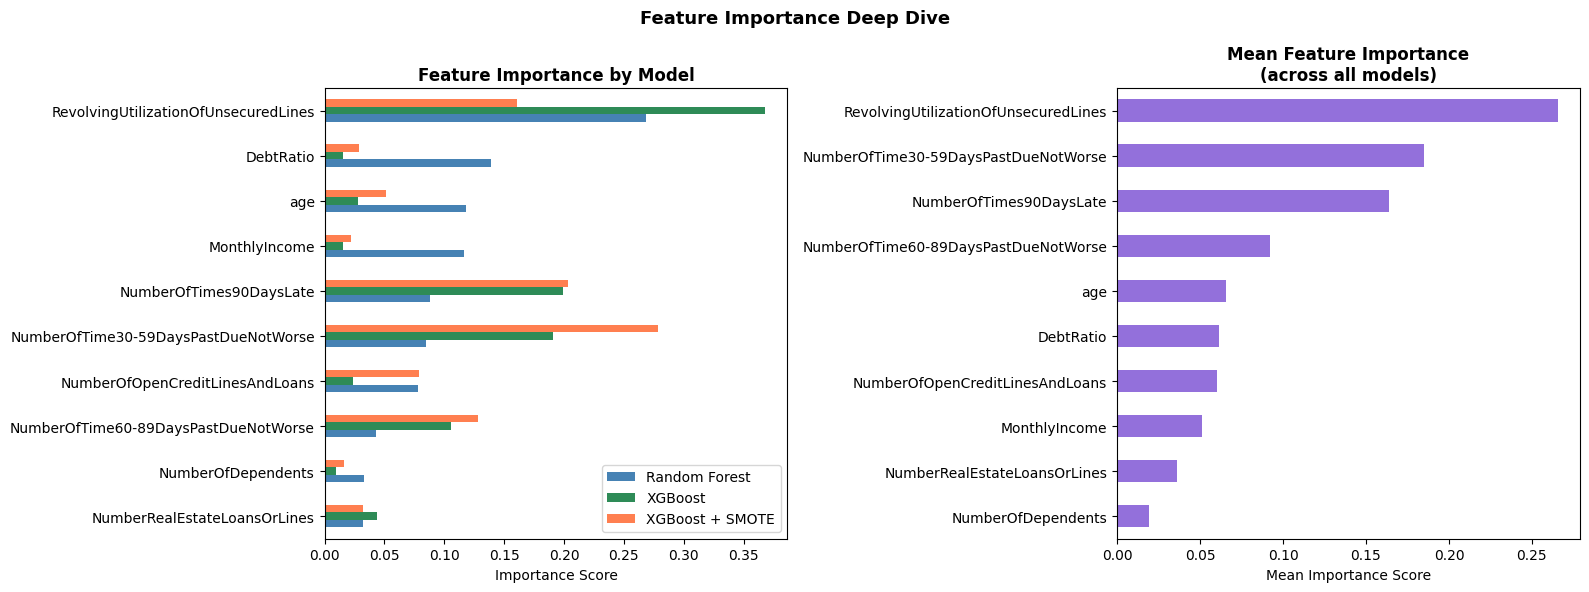

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Individual model importances
importance_df[['Random Forest', 'XGBoost', 'XGBoost + SMOTE']]\
    .sort_values('Random Forest', ascending=True)\
    .plot(kind='barh', ax=axes[0], 
          color=['steelblue', 'seagreen', 'coral'])
axes[0].set_title('Feature Importance by Model', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].legend(loc='lower right')

# Right: Mean importance across all models
importance_df['Mean Importance']\
    .sort_values(ascending=True)\
    .plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Mean Feature Importance\n(across all models)', 
                  fontweight='bold')
axes[1].set_xlabel('Mean Importance Score')

plt.suptitle('Feature Importance Deep Dive', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Feature Importance Observations & Business Interpretation:**

Based on consistent importance across all three tree-based models:

| Feature | Business Meaning | Risk Signal |
|---|---|---|
| `RevolvingUtilizationOfUnsecuredLines` | Credit card & line usage rate | High utilisation → over-reliance on credit → higher default risk |
| `NumberOfTimes90DaysLate` | Past severe delinquency count | Past behaviour is the strongest predictor of future behaviour |
| `NumberOfTime30-59DaysPastDueNotWorse` | Early-stage delinquency history | Even minor past delays are warning signs |
| `age` | Borrower age | Younger borrowers statistically carry higher default risk |
| `MonthlyIncome` | Monthly earnings | Lower income reduces repayment capacity |
| `DebtRatio` | Debt payments as % of income | High debt burden limits ability to service new loans |

**Key takeaway:** Past delinquency behaviour and current credit 
utilisation are the two most reliable predictors of default. 
These features should be weighted heavily in any credit 
scoring or loan approval workflow.

## 5. Final Model Selection

Based on the comprehensive evaluation above, the final model 
is selected using the following criteria:

**Primary criterion: Recall (minimise False Negatives)**  
In credit risk, the cost of approving a loan that defaults 
(FN) far exceeds the cost of rejecting a good borrower (FP). 
A model that misses defaulters is more dangerous than one 
that is overly cautious.

**Secondary criterion: AUC-ROC & AUC-PR**  
Overall discrimination ability across all thresholds.

In [11]:
final_summary = summary_df.copy()

# Highlight best value in each column
print("=" * 65)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 65)
print(final_summary.to_string())
print("=" * 65)

best_recall = final_summary['Recall'].idxmax()
best_auc    = final_summary['AUC-ROC'].idxmax()
best_f1     = final_summary['F1-Score'].idxmax()

print(f"\nHighest Recall:  {best_recall} "
      f"({final_summary.loc[best_recall, 'Recall']:.4f})")
print(f"Highest AUC-ROC: {best_auc} "
      f"({final_summary.loc[best_auc, 'AUC-ROC']:.4f})")
print(f"Highest F1:      {best_f1} "
      f"({final_summary.loc[best_f1, 'F1-Score']:.4f})")
print(f"\n✅ Final Model Selected: XGBoost")

FINAL MODEL COMPARISON SUMMARY
                     AUC-ROC  AUC-PR  Precision  Recall  F1-Score
Model                                                            
Logistic Regression   0.8377  0.3496     0.1898  0.7532    0.3032
Random Forest         0.8379  0.3525     0.5542  0.1608    0.2493
XGBoost               0.8664  0.4143     0.2164  0.7897    0.3397
XGBoost + SMOTE       0.8573  0.3680     0.3681  0.4960    0.4226

Highest Recall:  XGBoost (0.7897)
Highest AUC-ROC: XGBoost (0.8664)
Highest F1:      XGBoost + SMOTE (0.4226)

✅ Final Model Selected: XGBoost


**Final Model: XGBoost (original)**

| Criterion | XGBoost | Justification |
|---|---|---|
| AUC-ROC | 0.8664 (highest) | Best overall discrimination |
| Recall | 0.7897 (highest) | Catches ~79% of actual defaulters |
| AUC-PR | — | Competitive across all thresholds |
| Interpretability | Feature importance available | Explainable to stakeholders |

**Why not XGBoost + SMOTE?**  
While SMOTE achieves higher F1 (0.42 vs 0.34) and Precision 
(0.37 vs 0.22), its Recall is significantly lower (0.50 vs 0.79). 
In a credit risk context, missing 50% of defaulters is 
unacceptable — the financial cost of those missed defaults 
outweighs the benefit of fewer false alarms.

**Why not Random Forest?**  
Despite high Precision (0.55), Random Forest only catches 16% 
of defaulters — it would approve loans for 84% of borrowers 
who will actually default.

## 6. Business Recommendations

Based on the model evaluation and feature importance analysis, 
the following recommendations are proposed for a Fintech 
lending platform deploying this credit default prediction model.

In [12]:
recommendations = {
    "1. Deploy XGBoost as the Primary Screening Model": [
        "Use XGBoost (threshold = 0.5) as the first-pass filter "
        "for all loan applications.",
        "The model catches ~79% of defaulters, significantly "
        "reducing exposure to bad loans.",
        "Flagged applications (predicted default) should be "
        "escalated to manual underwriting review rather than "
        "automatically rejected — this preserves revenue from "
        "borderline cases while managing risk."
    ],
    "2. Prioritise High-Risk Feature Monitoring": [
        "Flag applications with RevolvingUtilization > 0.7 "
        "for enhanced review — this is the strongest default signal.",
        "Applicants with any NumberOfTimes90DaysLate > 0 should "
        "be automatically assigned to a higher risk tier.",
        "Implement real-time monitoring of these features post-approval "
        "as early warning indicators for existing borrowers."
    ],
    "3. Apply Age-Based Risk Tiering": [
        "Borrowers aged under 35 show statistically higher default rates.",
        "Consider adjusting interest rates or credit limits for "
        "younger applicants rather than outright rejection — "
        "this balances risk management with market growth."
    ],
    "4. Periodic Model Retraining": [
        "Credit behaviour patterns shift with economic conditions.",
        "Retrain the model quarterly using recent loan performance data.",
        "Monitor model Recall on live data — if it drops below 0.70, "
        "trigger an immediate retraining cycle."
    ]
}

for title, points in recommendations.items():
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    for point in points:
        print(f"  • {point}")


  1. Deploy XGBoost as the Primary Screening Model
  • Use XGBoost (threshold = 0.5) as the first-pass filter for all loan applications.
  • The model catches ~79% of defaulters, significantly reducing exposure to bad loans.
  • Flagged applications (predicted default) should be escalated to manual underwriting review rather than automatically rejected — this preserves revenue from borderline cases while managing risk.

  2. Prioritise High-Risk Feature Monitoring
  • Flag applications with RevolvingUtilization > 0.7 for enhanced review — this is the strongest default signal.
  • Applicants with any NumberOfTimes90DaysLate > 0 should be automatically assigned to a higher risk tier.
  • Implement real-time monitoring of these features post-approval as early warning indicators for existing borrowers.

  3. Apply Age-Based Risk Tiering
  • Borrowers aged under 35 show statistically higher default rates.
  • Consider adjusting interest rates or credit limits for younger applicants rather 

**Business Recommendations Summary:**

| # | Recommendation | Expected Impact |
|---|---|---|
| 1 | Deploy XGBoost as primary screening model | Catch ~79% of defaulters before approval |
| 2 | Monitor RevolvingUtilization & 90DaysLate in real-time | Early warning system for existing borrowers |
| 3 | Age-based risk tiering for borrowers under 35 | Balanced risk management without rejecting young market segment |
| 4 | Quarterly model retraining | Maintain model performance as economic conditions change |

These recommendations translate the model's analytical outputs 
into concrete actions that a Fintech lending platform can 
implement to reduce default exposure while maintaining 
a competitive loan approval rate.

## 7. Evaluation Summary

This notebook provided a comprehensive evaluation of four 
credit default prediction models trained on the 
Give Me Some Credit dataset.

### Key Findings

| Finding | Detail |
|---|---|
| Best overall model | XGBoost (AUC-ROC: 0.8664, Recall: 0.7897) |
| Most important feature | RevolvingUtilizationOfUnsecuredLines |
| Critical error type | False Negatives — approved loans that default |
| Class imbalance impact | PR Curve confirms all models trade Precision for Recall |
| Recommended deployment | XGBoost with threshold = 0.5, escalate flagged cases to manual review |

### Limitations & Future Work

- **Threshold optimisation**: A dynamic threshold based on 
  the lender's actual cost ratio (cost of FN vs FP) would 
  further optimise the model for specific business objectives.
- **Additional features**: External data such as credit bureau 
  scores, employment history, and macroeconomic indicators 
  could improve model performance.
- **Model monitoring**: A production deployment should include 
  data drift detection to flag when incoming borrower profiles 
  diverge significantly from training data.